# CDC API exploration

Probe the CDC MCP tools. The MCP server must be running (`python -m mcp_server.server`).

CDC data lives on a Socrata portal (`data.cdc.gov`); reading needs no credentials
(an optional `CDC_API_KEY` app token only raises rate limits). Each dataset has
its own schema, so **discover** a dataset, **inspect its columns**, then **query** it.

In [6]:
%reload_ext autoreload
%autoreload 2

import sys
from matplotlib import pyplot
from lib import config

sys.path.append('../')

from utils import (
    call_tool,
    list_mcp_tools,
    discover,
    show_columns,
    query_rows,
    plot_cdc_series,
    plot_cdc_series_by,
)

pyplot.style.use(config.glyfish_style)

## Available tools

In [7]:
await list_mcp_tools()

fred_category_children: List the child categories for a FRED category.
fred_category_series: List the series contained within a FRED category.
fred_series_info: Fetch metadata for a single FRED series.
fred_series_observations: Return observations for a series (limit defaults to 100).
fred_series_updates: Return recently updated FRED series.
list_releases: List FRED releases — the publications data arrives in, such as the Employment Situation or the H.15 selected interest rates. Returns the release ids that fred_release_series takes.
fred_release_series: List the series that belong to a FRED release.
tiingo_series_info: Fetch metadata for a Tiingo ticker (ETF, mutual fund, or stock), including its available date range.
tiingo_price_series: Return the end-of-day price series (OHLCV plus split/dividend-adjusted prices) for a Tiingo ticker. Provide start_date/end_date as YYYY-MM-DD for a range; omit for the latest day.
bls_series_data: Fetch observations for one or more BLS series IDs (up

## Discover datasets

Search the CDC catalog for the SDT health metrics — life expectancy and the
"deaths of despair" components (drug overdose, suicide).

In [8]:
await discover("life expectancy")

w9j2-ggv5      NCHS - Death rates and life expectancy at birth
ss2j-8ajj      U.S. State Life Expectancy by Sex, 2020
ncvk-7amm      U.S. State Life Expectancy by Sex, 2019
it4f-frdc      U.S. State Life Expectancy by Sex, 2021
5h56-n989      U.S. Life Expectancy at Birth by State and Census Tract - 2010-2015
a5a8-jsrq      U.S. State Life Expectancy by Sex, 2018
v5gm-kvkn      Health, United States
e6et-eg6c      Diabetes State Burden Toolkit - Diabetes Mortality and Health-related Quality of Life
nnvr-zdhw      An Investigation Into the Relationship Between Coal Workers’ Pneumoconiosis and Dust Exposure in U.S. Coal Miners


[{'id': 'w9j2-ggv5',
  'name': 'NCHS - Death rates and life expectancy at birth',
  'description': 'This dataset of U.S. mortality trends since 1900 highlights the differences in age-adjusted death rates and life expectancy at birth by race and sex.\n\nAge-adjusted death rates (deaths per 100,000) after 1998 are calculated based on the 2000 U.S. standard population. Populations used for computing death rates for 2011–2017 are postcensal estimates based on the 2010 census, estimated as of July 1, 2010. Rates for census years are based on populations enumerated in the corresponding censuses. Rates for noncensus years between 2000 and 2010 are revised using updated intercensal population estimates and may differ from rates previously published. Data on age-adjusted death rates prior to 1999 are taken from historical data (see References below).\n\nLife expectancy data are available up to 2017. Due to changes in categories of race used in publications, data are not available for the black 

In [9]:
await discover("drug overdose deaths")

xkb8-kh2a      VSRR Provisional Drug Overdose Death Counts
gb4e-yj24      VSRR Provisional County-Level Drug Overdose Death Counts
8hzs-zshh      Provisional drug overdose death counts for specific drugs
95ax-ymtc      Drug overdose death rates, by drug type, sex, age, race, and Hispanic origin: United States
dtm2-meqi      Provisional Drug Overdose Deaths by Urban/Rural Classification Scheme for 12 month-ending December 2018-December 2020
rdjz-vn2n      DQS Drug overdose death rates, by drug type, sex, age, race, and Hispanic origin: United States from CDC WONDER
v2g4-wqg2      Early Model-based Provisional Estimates of Drug Overdose, Suicide, and Transportation-related Deaths
9dzk-mvmi      Monthly Provisional Counts of Deaths by Select Causes, 2020-2023
4day-mt2f      Mapping Injury, Overdose, and Violence - Census Tract
psx4-wq38      Mapping Injury, Overdose, and Violence - County


[{'id': 'xkb8-kh2a',
  'name': 'VSRR Provisional Drug Overdose Death Counts',
  'description': 'This data presents provisional counts for drug overdose deaths based on a current flow of mortality data in the National Vital Statistics System. Counts for the most recent final annual data are provided for comparison. National provisional counts include deaths occurring within the 50 states and the District of Columbia as of the date specified and may not include all deaths that occurred during a given time period. Provisional counts are often incomplete and causes of death may be pending investigation resulting in an underestimate relative to final counts. To address this, methods were developed to adjust provisional counts for reporting delays by generating a set of predicted provisional counts.\n\nSeveral data quality metrics, including the percent completeness in overall death reporting, percentage of deaths with cause of death pending further investigation, and the percentage of drug 

In [10]:
await discover("suicide")

9j2v-jamp      Death rates for suicide, by sex, race, Hispanic origin, and age: United States
v2g4-wqg2      Early Model-based Provisional Estimates of Drug Overdose, Suicide, and Transportation-related Deaths
9dzk-mvmi      Monthly Provisional Counts of Deaths by Select Causes, 2020-2023
w26f-tf3h      DQS Death rates for suicide, by sex, race, Hispanic origin, and age: United States from CDC WONDER
489q-934x      NCHS - VSRR Quarterly provisional estimates for selected indicators of mortality
bxq8-mugm      Monthly Counts of Deaths by Select Causes, 2014-2019
4day-mt2f      Mapping Injury, Overdose, and Violence - Census Tract
psx4-wq38      Mapping Injury, Overdose, and Violence - County
fpsi-y8tj      Mapping Injury, Overdose, and Violence - State
t6u2-f84c      Mapping Injury, Overdose, and Violence - National


[{'id': '9j2v-jamp',
  'name': 'Death rates for suicide, by sex, race, Hispanic origin, and age: United States',
  'description': 'Data on death rates for suicide, by selected population characteristics. Please refer to the PDF or Excel version of this table in the HUS 2019 Data Finder (https://www.cdc.gov/nchs/hus/contents2019.htm) for critical information about measures, definitions, and changes over time. \n\nSOURCE: NCHS, National  Vital Statistics System (NVSS); Grove RD, Hetzel AM. Vital statistics rates in the United States, 1940–1960. National Center for Health Statistics. 1968; numerator data from NVSS annual public-use Mortality Files; denominator data from U.S. Census Bureau national population estimates; and Murphy SL, Xu JQ, Kochanek KD, Arias E, Tejada-Vera B. Deaths: Final data for 2018. National Vital Statistics Reports; vol 69 no 13. Hyattsville, MD: National Center for Health Statistics. 2021. Available from: https://www.cdc.gov/nchs/products/nvsr.htm. For more inform

In [11]:
await discover("alcohol")

haed-k2ka      Occupant and Alcohol-Impaired Driving Deaths in States, 2005-2014
grbx-2j68      Graph of Alcohol Use 3 Months Before and Last 3 Months of Pregnancy
hfr9-rurv      Alzheimer's Disease and Healthy Aging Data
hksd-2xuw      U.S. Chronic Disease Indicators
xs7u-t3bn      Alzheimer's Disease and Healthy Aging Indicators: Caregiving
jhd5-u276      Alzheimer's Disease and Healthy Aging Indicators: Cognitive Decline
mtgp-t7vw      DQS Use of selected substances in the past 30 days among 12th graders, 10th graders, and 8th graders, by sex and race: United States.
mbvg-apdj      Graph of Tobacco Use 3 Months Before and Last 3 Months of Pregnancy
dnxe-zgxs      CDC PRAMStat Data for 2002
4ya2-fkvt      CDC PRAMStat Data for 2008


[{'id': 'haed-k2ka',
  'name': 'Occupant and Alcohol-Impaired Driving Deaths in States, 2005-2014',
  'description': "Alcohol-Impaired Driving Fatalities 2005-2014; All persons killed in crashes involving a driver with BAC >= .08 g/dL. Occupant Fatalities 2005-2014; All occupants killed where body type = 1-79. Source: National Highway Traffic Safety Administration's (NHTSA) Fatality Analysis Reporting System (FARS), 2005-2013 Final Reports and 2014 Annual Report File",
  'domain': 'data.cdc.gov'},
 {'id': 'grbx-2j68',
  'name': 'Graph of Alcohol Use 3 Months Before and Last 3 Months of Pregnancy',
  'description': '2011.  Centers for Disease Control and Prevention (CDC).  PRAMS, the Pregnancy Risk Assessment Monitoring System, is a surveillance system collecting state-specific, population-based data on maternal attitudes and experiences before, during, and shortly after pregnancy. It is a collaborative project of the Centers for Disease Control and Prevention (CDC) and state health dep

## Inspect a dataset's columns

Schemas differ per dataset, so check the columns to find the time / value / facet
fields. `w9j2-ggv5` is death rates & life expectancy (1900→), keyed by year × race × sex.

In [12]:
await show_columns("w9j2-ggv5")

w9j2-ggv5: NCHS - Death rates and life expectancy at birth
  year                             number   Year
  race                             text     Race
  sex                              text     Sex
  average_life_expectancy          number   Average Life Expectancy (Years)
  mortality                        number   Age-adjusted Death Rate


[{'field_name': 'year',
  'name': 'Year',
  'data_type': 'number',
  'description': None,
  'cached_top': [{'item': '1972', 'count': 9},
   {'item': '2000', 'count': 9},
   {'item': '1951', 'count': 9},
   {'item': '1970', 'count': 9},
   {'item': '1931', 'count': 9},
   {'item': '1934', 'count': 9},
   {'item': '1907', 'count': 9},
   {'item': '1961', 'count': 9},
   {'item': '1952', 'count': 9},
   {'item': '2017', 'count': 9},
   {'item': '1981', 'count': 9},
   {'item': '1976', 'count': 9},
   {'item': '2018', 'count': 9},
   {'item': '1937', 'count': 9},
   {'item': '1998', 'count': 9},
   {'item': '1974', 'count': 9},
   {'item': '1936', 'count': 9},
   {'item': '1973', 'count': 9},
   {'item': '1982', 'count': 9},
   {'item': '1909', 'count': 9}],
  'cached_smallest': '1900',
  'cached_largest': '2018',
  'cached_non_null': 1071,
  'cached_null': 0},
 {'field_name': 'race',
  'name': 'Race',
  'data_type': 'text',
  'description': None,
  'cached_top': [{'item': 'White', 'count'

## Query a series

Life expectancy for all races / both sexes over the full record. `where` is a
SoQL predicate; Socrata returns values as strings.

In [13]:
rows = await query_rows(
    "w9j2-ggv5",
    where="race='All Races' AND sex='Both Sexes'",
    order="year",
)
print(len(rows), "rows")
rows[0]

119 rows


{'year': '1900',
 'race': 'All Races',
 'sex': 'Both Sexes',
 'average_life_expectancy': '47.3',
 'mortality': '2518.0'}

## Plot

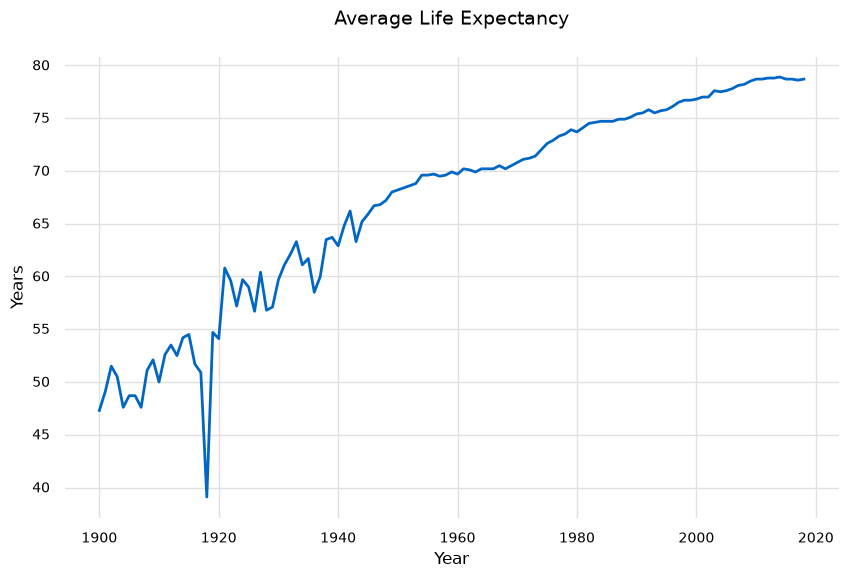

In [14]:
plot_cdc_series(rows, "year", "average_life_expectancy", ylabel="Years")

## Life expectancy by sex and by race

The plot above is the aggregate — `All Races` / `Both Sexes`. Break it out one
facet at a time, holding the other facet at its aggregate, and overlay the groups
on a single shared scale with `plot_cdc_series_by`. The helper drops the
facet-wide total (`Both Sexes`, `All Races`) so the breakdown stays readable, and
reuses `cdc_rows_to_arrays` to skip the suppressed 2018 `Black`/`White`
life-expectancy cells — so those lines end at 2017 while `All Races` runs to 2018.

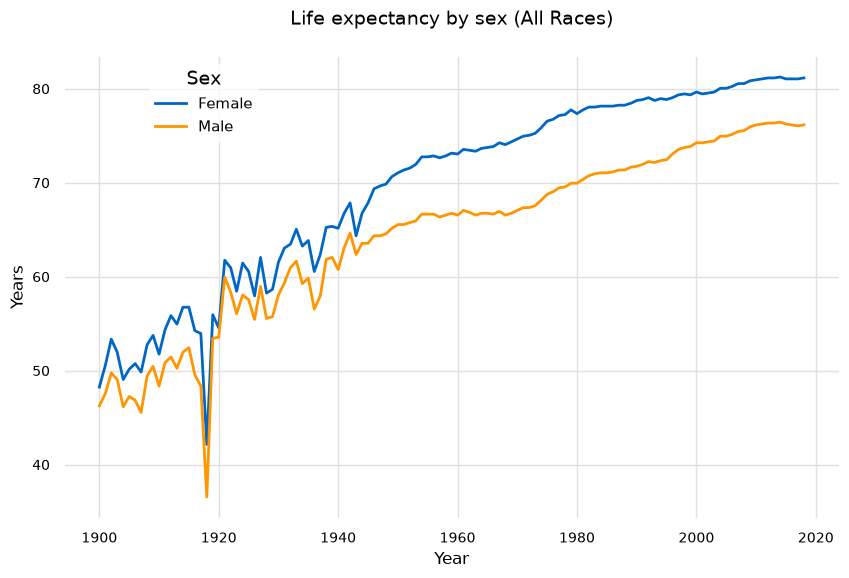

In [15]:
# By sex, holding race constant at the 'All Races' aggregate.
by_sex = await query_rows(
    "w9j2-ggv5",
    where="race='All Races'",
    order="sex, year",
)
plot_cdc_series_by(
    by_sex, "year", "average_life_expectancy", "sex",
    title="Life expectancy by sex (All Races)", ylabel="Years",
)

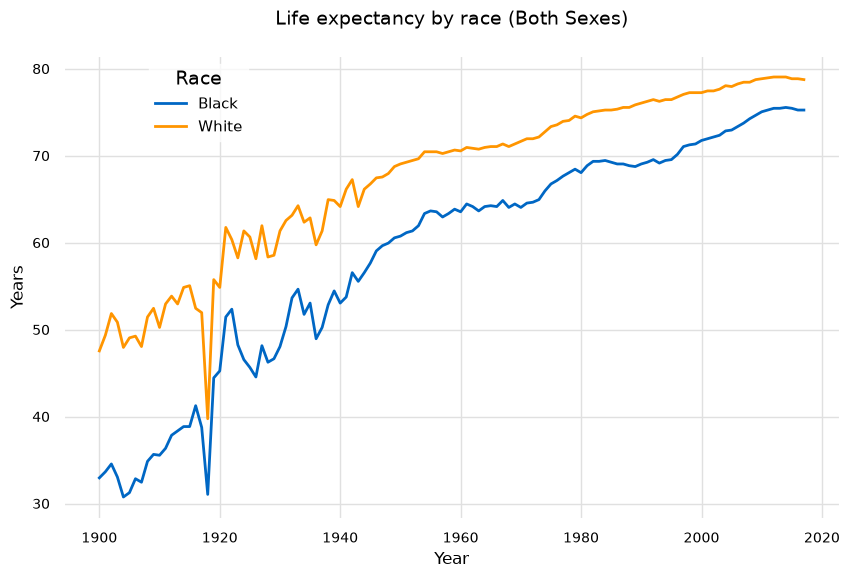

In [16]:
# By race, holding sex constant at the 'Both Sexes' aggregate.
by_race = await query_rows(
    "w9j2-ggv5",
    where="sex='Both Sexes'",
    order="race, year",
)
plot_cdc_series_by(
    by_race, "year", "average_life_expectancy", "race",
    title="Life expectancy by race (Both Sexes)", ylabel="Years",
)

### Keep the overall aggregate for reference

Pass `exclude=()` to keep the facet-wide total in the overlay. Here the
`Both Sexes` average is labeled alongside the `Female` and `Male` lines as the
overall reference baseline.

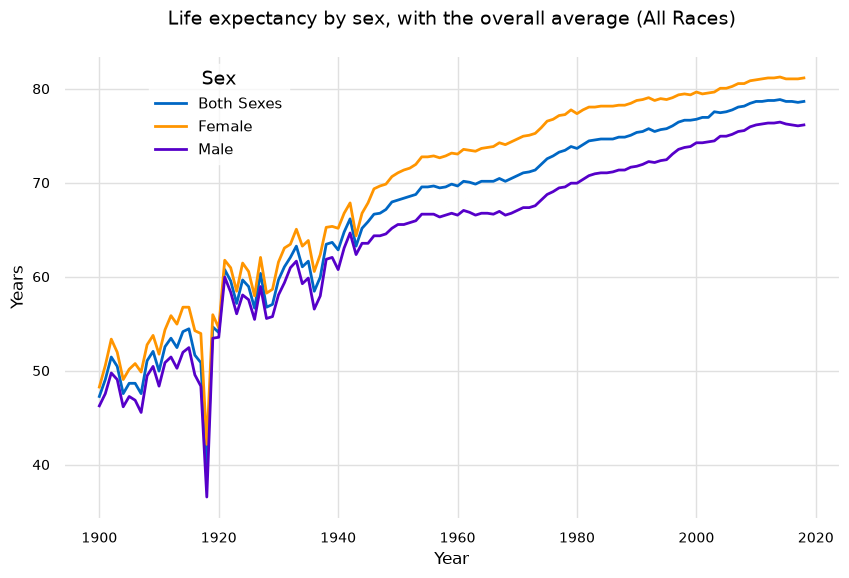

In [17]:
# exclude=() keeps 'Both Sexes' so the overall average is labeled for reference.
plot_cdc_series_by(
    by_sex, "year", "average_life_expectancy", "sex", exclude=(),
    title="Life expectancy by sex, with the overall average (All Races)",
    ylabel="Years",
)

## Deaths-of-despair components

Suicide death rates (`9j2v-jamp`, NCHS stub schema) — all persons, all ages.
Overdose counts (`xkb8-kh2a`) are monthly/provisional by state and drug type, so
they need a different time field (`year` + `month`) and value (`data_value`).

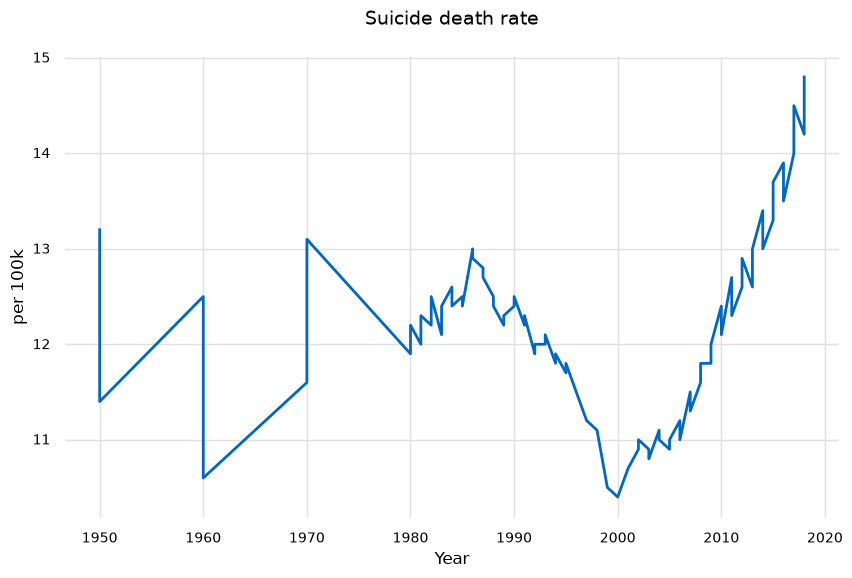

In [18]:
suicide = await query_rows(
    "9j2v-jamp",
    where="stub_label='All persons' AND age='All ages'",
    order="year",
)
plot_cdc_series(suicide, "year", "estimate", title="Suicide death rate", ylabel="per 100k")